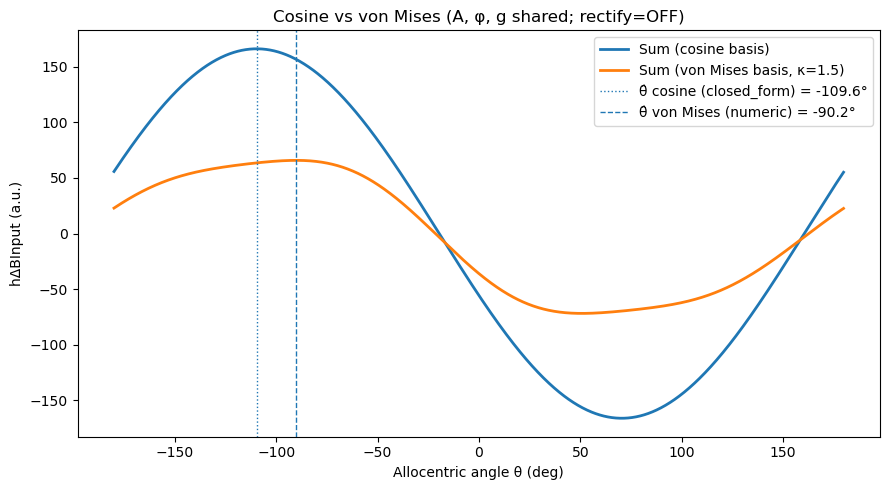

{'theta_cos': -109.62056329858102,
 'theta_vm': -90.25,
 'delta_vm_minus_cos_deg': 19.370563298581033}

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Helpers ----------------
def d2r(x): return np.deg2rad(x)
def r2d(x): return np.rad2deg(x)
def wrap180(a): return (a + 180) % 360 - 180
def wrap360(a):
    # Wrap to [0, 360)
    return float(np.mod(a, 360.0)) if np.isscalar(a) else np.mod(a, 360.0)

# ---------------- Paper params ----------------
PHI_DEFAULT = np.array([ 45.0, -45.0, +135.0, -135.0 ], dtype=float)
G_DEFAULT   = np.array([ 92.9,  98.0,   67.0,  74.3 ], dtype=float)
AXES_EGO    = np.array([+45.0, -45.0, +135.0, -135.0], dtype=float)

# ---------------- Core model ----------------
def pfn_amplitudes_from_egocentric(Te_deg, rectify=False):
    vals = np.cos(d2r(Te_deg - AXES_EGO))
    if rectify:
        vals = np.maximum(0.0, vals)
    return vals  # (4,)

def pfn_i_theta(theta_deg, H_deg, phi_i_deg, Ai, ai=0.0, ci=0.0, basis="cosine", kappa=5.0):
    x = d2r(-H_deg - theta_deg - phi_i_deg)
    if basis == "cosine":
        base = np.cos(x)
    elif basis == "von_mises":
        base = np.exp(kappa * np.cos(x))
        base /= np.max(base)  # normalize peak to 1 so Ai controls amplitude
    else:
        raise ValueError("basis must be 'cosine' or 'von_mises'")
    return Ai * (ai + base) + ci

def hDeltaB_input(theta_deg, H_deg, phi_deg, g, A, basis="cosine", kappa=5.0, ai=0.0, ci=0.0):
    total = np.zeros_like(theta_deg, dtype=float)
    for gi, phii, Ai in zip(g, phi_deg, A):
        total += gi * pfn_i_theta(theta_deg, H_deg, phii, Ai, ai=ai, ci=ci, basis=basis, kappa=kappa)
    return total

def theta_max_numeric(H_deg, phi_deg, g, A, basis="cosine", kappa=4.0, ai=0.0, ci=0.0, grid_deg=0.25):
    """Numeric argmax over θ ∈ [-180, 180). Works for both bases."""
    theta = np.arange(-180.0, 180.0, grid_deg)
    y = hDeltaB_input(theta, H_deg, phi_deg, g, A, basis=basis, kappa=kappa, ai=ai, ci=ci)
    th = float(theta[np.argmax(y)])
    return th, theta, y

def theta_max_closed_form(H_deg, phi_deg, g, A):
    """
    Closed-form for pure cosine basis with unrectified A (and θ-independent offsets):
      θ_max = -atan2( Σ g_i A_i sin φ_i , Σ g_i A_i cos φ_i ) - H
    """
    s = np.sum(g * A * np.sin(d2r(phi_deg)))
    c = np.sum(g * A * np.cos(d2r(phi_deg)))
    theta_rel = -r2d(np.arctan2(s, c))  # relative to H
    th = theta_rel - H_deg
    return wrap180(th), wrap360(th)

# ---------------- One-figure comparison ----------------
def plot_basis_comparison(
    H_deg=30.0,
    Te_deg=-60.0,
    *,
    kappa=5.0,
    rectify=False,
    grid_deg=0.25,
    decode_cos='numeric',         # 'numeric' | 'closed_form' | 'none'
    decode_vm='numeric',          # 'numeric' | 'closed_form' | 'none'
    cf_use_unrectified_A=True,    # closed-form uses unrectified A (paper-like)
    allow_vm_cf_proxy=True        # allow cosine closed-form as a proxy for von Mises
):
    """
    Overlay cosine vs von Mises (same A, φ, g). Optional vertical decode lines.
    """
    phi = PHI_DEFAULT
    g   = G_DEFAULT

    # Amplitudes
    A_num = pfn_amplitudes_from_egocentric(Te_deg, rectify=rectify)
    A_cf  = pfn_amplitudes_from_egocentric(Te_deg, rectify=False) if cf_use_unrectified_A else A_num

    # θ grid and curves
    theta_grid = np.arange(-180.0, 180.0, grid_deg)
    y_cos = hDeltaB_input(theta_grid, H_deg, phi, g, A_num, basis="cosine")
    y_vm  = hDeltaB_input(theta_grid, H_deg, phi, g, A_num, basis="von_mises", kappa=kappa)

    # --- Decode choices ---
    th_cos = None
    if decode_cos == 'numeric':
        th_cos, *_ = theta_max_numeric(H_deg, phi, g, A_num, basis="cosine", grid_deg=grid_deg)
    elif decode_cos == 'closed_form':
        th_cos, _ = theta_max_closed_form(H_deg, phi, g, A_cf)
    elif decode_cos in (None, 'none'):
        th_cos = None
    else:
        raise ValueError("decode_cos must be 'numeric', 'closed_form', or 'none'.")

    th_vm = None
    if decode_vm == 'numeric':
        th_vm, *_ = theta_max_numeric(H_deg, phi, g, A_num, basis="von_mises", kappa=kappa, grid_deg=grid_deg)
    elif decode_vm == 'closed_form':
        if not allow_vm_cf_proxy:
            print("Note: closed_form for von Mises is a cosine closed-form proxy. "
                  "Set allow_vm_cf_proxy=True to enable.")
        else:
            th_vm, _ = theta_max_closed_form(H_deg, phi, g, A_cf)  # proxy
    elif decode_vm in (None, 'none'):
        th_vm = None
    else:
        raise ValueError("decode_vm must be 'numeric', 'closed_form', or 'none'.")

    # --- Plot ---
    plt.figure(figsize=(9, 5))
    plt.plot(theta_grid, y_cos, linewidth=2, label="Sum (cosine basis)")
    plt.plot(theta_grid, y_vm,  linewidth=2, label=f"Sum (von Mises basis, κ={kappa})")

    if th_cos is not None:
        ls = '--' if decode_cos == 'numeric' else ':'
        plt.axvline(th_cos, linestyle=ls, linewidth=1,
                    label=f"θ̂ cosine ({decode_cos}) = {th_cos:.1f}°")

    if th_vm is not None:
        ls = '--' if decode_vm == 'numeric' else ':'
        tag = "proxy closed-form" if (decode_vm == 'closed_form') else 'numeric'
        plt.axvline(th_vm, linestyle=ls, linewidth=1,
                    label=f"θ̂ von Mises ({tag}) = {th_vm:.1f}°")

    plt.xlabel("Allocentric angle θ (deg)")
    plt.ylabel("hΔBInput (a.u.)")
    plt.title(f"Cosine vs von Mises (A, φ, g shared; rectify={'ON' if rectify else 'OFF'})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    out = {"theta_cos": th_cos, "theta_vm": th_vm}
    if (th_cos is not None) and (th_vm is not None):
        out["delta_vm_minus_cos_deg"] = wrap180(th_vm - th_cos)
    return out

# ---- Demo with defaults ----
plot_basis_comparison(H_deg=20, Te_deg=90, kappa=1.5, rectify=False,
                      decode_cos='closed_form', decode_vm='numeric')



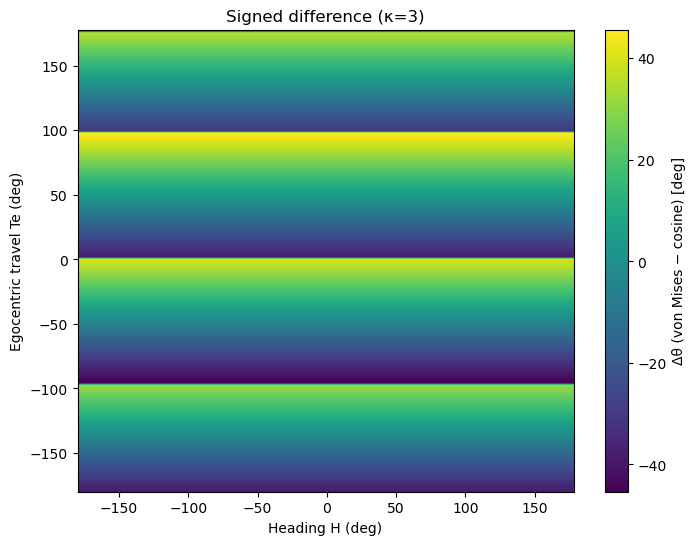

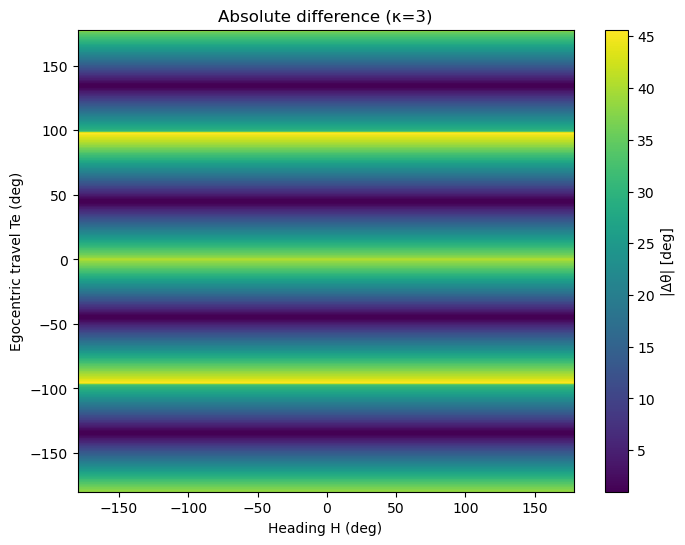

In [16]:
# ===================== Heatmap computation =====================
GRID_DEG = 2.0      # step for H and Te grid
VM_GRID  = 0.5      # theta grid step for numeric argmax
KAPPA    = 3     # von Mises sharpness

H_vals  = np.arange(-180.0, 180.0, GRID_DEG)
Te_vals = np.arange(-180.0, 180.0, GRID_DEG)

diff_map = np.zeros((len(Te_vals), len(H_vals)))
abs_diff_map = np.zeros_like(diff_map)

for i, Te in enumerate(Te_vals):
    A = pfn_amplitudes_from_egocentric(Te, rectify=False)
    for j, H in enumerate(H_vals):
        th_cos, _ = theta_max_closed_form(H, PHI_DEFAULT, G_DEFAULT, A)  # closed-form → tuple; take wrap180

        th_vm, _, _ = theta_max_numeric(  # numeric → 3 returns; take only angle
            H, PHI_DEFAULT, G_DEFAULT, A,
            basis="von_mises", kappa=KAPPA, grid_deg=VM_GRID
        )

        diff_map[i, j] = wrap180(th_vm - th_cos)
        abs_diff_map[i, j] = abs(diff_map[i, j])



# ---- Plot signed difference ----
plt.figure(figsize=(8, 6))
plt.imshow(diff_map, origin='lower',
           extent=[H_vals[0], H_vals[-1], Te_vals[0], Te_vals[-1]],
           aspect='auto')
plt.colorbar(label="Δθ (von Mises − cosine) [deg]")
plt.xlabel("Heading H (deg)")
plt.ylabel("Egocentric travel Te (deg)")
plt.title(f"Signed difference (κ={KAPPA})")
plt.show()

# ---- Plot absolute difference ----
plt.figure(figsize=(8, 6))
plt.imshow(abs_diff_map, origin='lower',
           extent=[H_vals[0], H_vals[-1], Te_vals[0], Te_vals[-1]],
           aspect='auto')
plt.colorbar(label="|Δθ| [deg]")
plt.xlabel("Heading H (deg)")
plt.ylabel("Egocentric travel Te (deg)")
plt.title(f"Absolute difference (κ={KAPPA})")
plt.show()


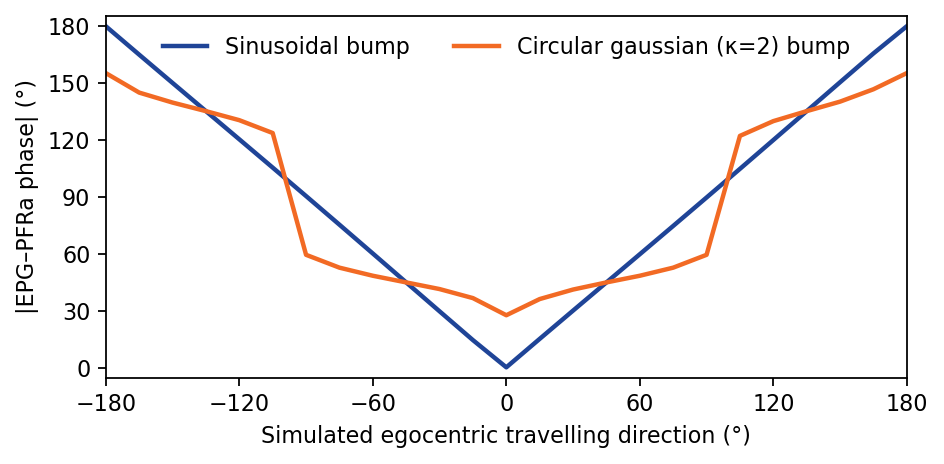

In [45]:
# Re-run after state reset: include all helpers and plot again.

import numpy as np
import matplotlib.pyplot as plt

def d2r(x): return np.deg2rad(x)
def r2d(x): return np.rad2deg(x)
def wrap180(a): return (a + 180) % 360 - 180
def wrap360(a): return float(np.mod(a, 360.0)) if np.isscalar(a) else np.mod(a, 360.0)

PHI_DEFAULT = np.array([ 45.0, -45.0, +135.0, -135.0 ], dtype=float)
G_DEFAULT   = np.array([ 92.9,  98.0,   67.0,  74.3 ], dtype=float)
AXES_EGO    = np.array([+45.0, -45.0, +135.0, -135.0], dtype=float)

def pfn_amplitudes_from_egocentric(Te_deg, rectify=False):
    vals = np.cos(d2r(Te_deg - AXES_EGO))
    return np.maximum(0.0, vals) if rectify else vals

def pfn_i_theta(theta_deg, H_deg, phi_i_deg, Ai, ai=0.0, ci=0.0, basis="cosine", kappa=5.0):
    x = d2r(-H_deg - theta_deg - phi_i_deg)
    if basis == "cosine":
        base = np.cos(x)
    elif basis == "von_mises":
        base = np.exp(kappa * np.cos(x))
        base /= np.max(base)
    else:
        raise ValueError("basis must be 'cosine' or 'von_mises'")
    return Ai * (ai + base) + ci

def hDeltaB_input(theta_deg, H_deg, phi_deg, g, A, basis="cosine", kappa=5.0, ai=0.0, ci=0.0):
    total = np.zeros_like(theta_deg, dtype=float)
    for gi, phii, Ai in zip(g, phi_deg, A):
        total += gi * pfn_i_theta(theta_deg, H_deg, phii, Ai, ai=ai, ci=ci, basis=basis, kappa=kappa)
    return total

def theta_max_numeric(H_deg, phi_deg, g, A, basis="cosine", kappa=4.0, ai=0.0, ci=0.0, grid_deg=0.25):
    theta = np.arange(-180.0, 180.0, grid_deg)
    y = hDeltaB_input(theta, H_deg, phi_deg, g, A, basis=basis, kappa=kappa, ai=ai, ci=ci)
    th = float(theta[np.argmax(y)])
    return th, theta, y

def theta_max_closed_form(H_deg, phi_deg, g, A):
    s = np.sum(g * A * np.sin(d2r(phi_deg)))
    c = np.sum(g * A * np.cos(d2r(phi_deg)))
    theta_rel = -r2d(np.arctan2(s, c))
    th = theta_rel - H_deg
    return wrap180(th), wrap360(th)

KAPPA = 2
TE_SAMPLES = np.arange(-180, 181, 15)
H0 = 0.0

abs_epg_pfr_cos = []
abs_epg_pfr_vm  = []
for Te in TE_SAMPLES:
    A = pfn_amplitudes_from_egocentric(Te, rectify=False)

    th_cos, _ = theta_max_closed_form(H0, PHI_DEFAULT, G_DEFAULT, A)
    abs_epg_pfr_cos.append(abs(wrap180(H0 - th_cos)))

    th_vm, *_ = theta_max_numeric(H0, PHI_DEFAULT, G_DEFAULT, A,
                                  basis="von_mises", kappa=KAPPA, grid_deg=0.25)
    abs_epg_pfr_vm.append(abs(wrap180(H0 - th_vm)))

abs_epg_pfr_cos = np.array(abs_epg_pfr_cos)
abs_epg_pfr_vm  = np.array(abs_epg_pfr_vm)
ideal = np.abs(TE_SAMPLES.astype(float))

plt.figure(figsize=(6, 3), dpi=160)
#plt.plot(TE_SAMPLES, ideal, linestyle="--", linewidth=1, label="Ideal |Te|")
plt.plot(TE_SAMPLES, abs_epg_pfr_cos, linewidth=2, color = '#1f4497', label="Sinusoidal bump")
plt.plot(TE_SAMPLES, abs_epg_pfr_vm,  linewidth=2, color = '#f26a24', label=f"Circular gaussian (κ={KAPPA}) bump")
plt.xlim(-180, 180)
plt.ylim(-5, 185)
plt.yticks([0, 30, 60, 90, 120, 150, 180])
plt.xticks([-180, -120, -60, 0, 60, 120, 180])
plt.xlabel("Simulated egocentric travelling direction (°)")
plt.ylabel("|EPG–PFRa phase| (°)")
plt.legend(frameon=False, loc="upper center", ncol=2)
plt.tight_layout()
#plt.savefig('Cosince_vs_vonmises_allocentric_decoding_difference.svg', format='svg')
plt.show()


